Creating sample dataset for demonstration...
Sample dataset created: sales_data.csv

First 5 rows of the dataset:
                     Order_Date Product_Category  Unit_Price  Quantity Region  \
0 2023-01-01 00:00:00.000000000       Home Goods      485.10         1  North   
1 2023-01-04 16:14:32.727272727            Books      389.82         1  North   
2 2023-01-08 08:29:05.454545454      Electronics      470.35         3   East   
3 2023-01-12 00:43:38.181818181       Home Goods      448.47         2   West   
4 2023-01-15 16:58:10.909090909       Home Goods      302.97         5   East   

   Revenue  Profit  
0   485.10  164.32  
1   389.82  143.06  
2  1411.05  284.18  
3   896.94  190.76  
4  1514.85  194.20  

Cleaning the dataset...
Removed 0 rows with missing values


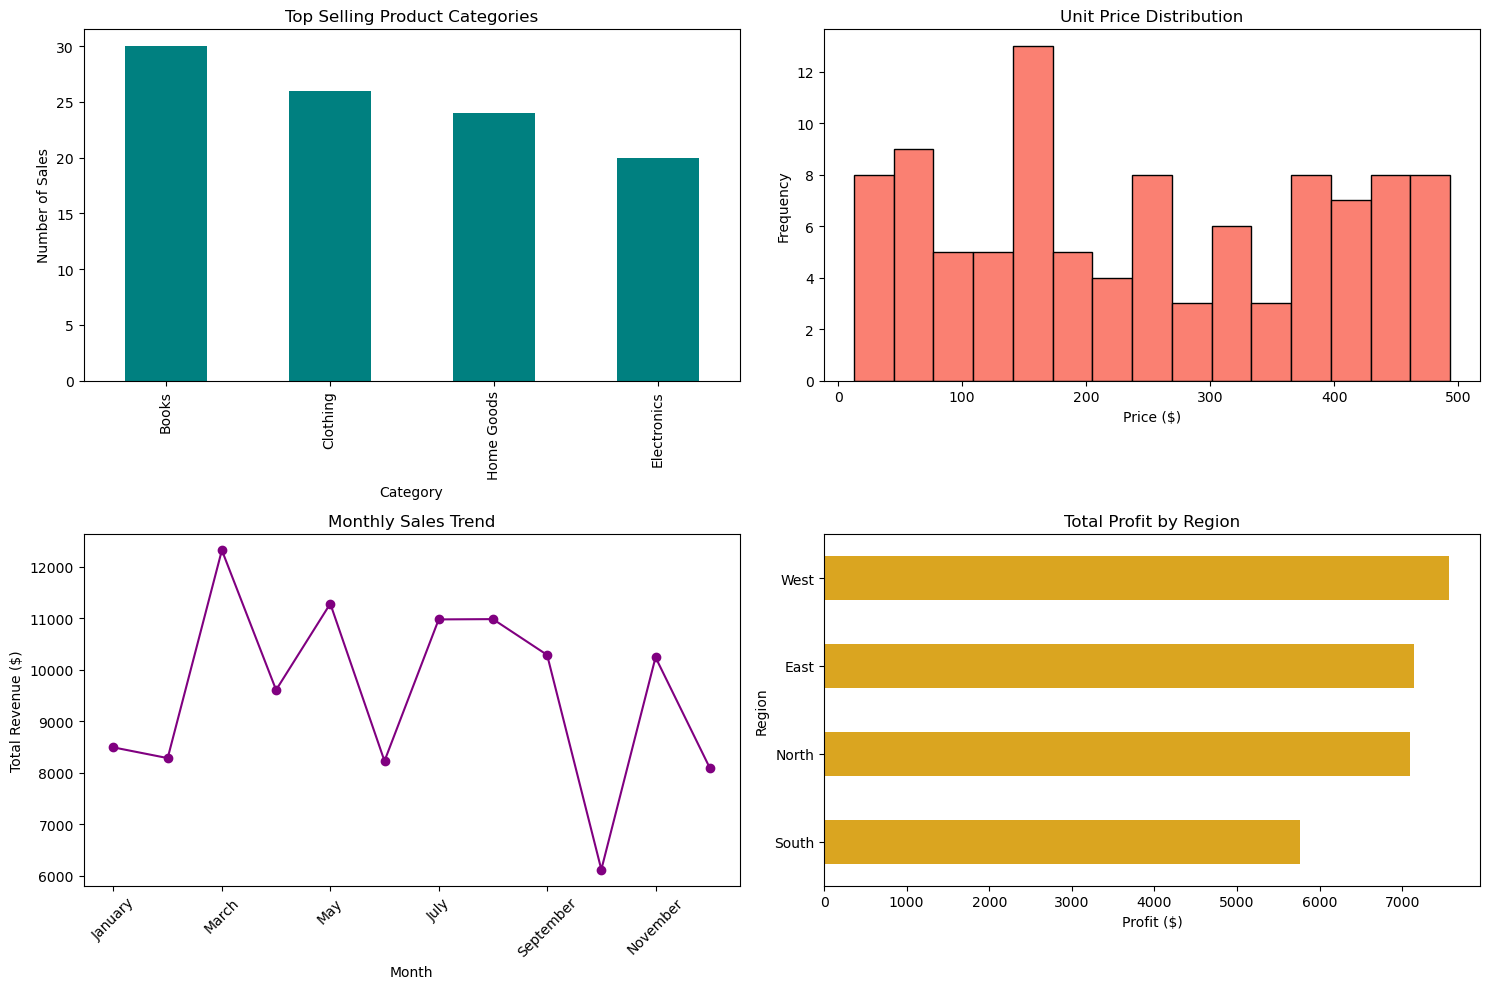


Key Findings:
1. Best selling category: Books
2. Average profit margin: 23.5%
3. Most profitable region: West
4. Total revenue generated: $114,898.46


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Create Sample Dataset if file not found ---
try:
    df = pd.read_csv("sales_data.csv")
except FileNotFoundError:
    print("Creating sample dataset for demonstration...")
    np.random.seed(42)
    
    # Generate sample data
    data = {
        'Order_Date': pd.date_range(start='2023-01-01', end='2023-12-31', periods=100),
        'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home Goods', 'Books'], 100),
        'Unit_Price': np.round(np.random.uniform(10, 500, 100), 2),
        'Quantity': np.random.randint(1, 10, 100),
        'Region': np.random.choice(['West', 'East', 'North', 'South'], 100)
    }
    
    # Calculate derived fields
    data['Revenue'] = np.round(data['Unit_Price'] * data['Quantity'], 2)
    data['Profit'] = np.round(data['Revenue'] * np.random.uniform(0.1, 0.4, 100), 2)
    
    df = pd.DataFrame(data)
    df.to_csv("sales_data.csv", index=False)
    print("Sample dataset created: sales_data.csv")

# --- Continue with Analysis ---
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Data cleaning
print("\nCleaning the dataset...")
# Handle missing values (if any in generated data)
initial_rows = len(df)
df.dropna(inplace=True)
print(f"Removed {initial_rows - len(df)} rows with missing values")

# --- Visualizations ---
plt.figure(figsize=(15, 10))

# 1. Top Selling Categories
plt.subplot(2, 2, 1)
df['Product_Category'].value_counts().plot(kind='bar', color='teal')
plt.title('Top Selling Product Categories')
plt.xlabel('Category')
plt.ylabel('Number of Sales')

# 2. Price Distribution
plt.subplot(2, 2, 2)
plt.hist(df['Unit_Price'], bins=15, color='salmon', edgecolor='black')
plt.title('Unit Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

# 3. Monthly Sales Trend
plt.subplot(2, 2, 3)
df['Month'] = df['Order_Date'].dt.month_name()
monthly_sales = df.groupby('Month')['Revenue'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

# 4. Regional Profit Analysis
plt.subplot(2, 2, 4)
df.groupby('Region')['Profit'].sum().sort_values().plot(
    kind='barh', color='goldenrod'
)
plt.title('Total Profit by Region')
plt.xlabel('Profit ($)')

plt.tight_layout()
plt.show()

# --- Analysis Results ---
print("\nKey Findings:")
print(f"1. Best selling category: {df['Product_Category'].mode()[0]}")
print(f"2. Average profit margin: {np.mean(df['Profit']/df['Revenue']):.1%}")
print(f"3. Most profitable region: {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"4. Total revenue generated: ${df['Revenue'].sum():,.2f}")